1. Load any 3 sample images (your choice: selfies, food, cricket, or memes) and use OpenCV or PIL to resize each to 224x224 pixels, saving the resized versions in a new folder.

In [14]:
import cv2
import os

input_images = [
    "image_1.jpg",
    "image_2.jpg",
    "image_3.jpg"
]

output_folder = "resized_images"
os.makedirs(output_folder, exist_ok=True)

for img_path in input_images:
    img = cv2.imread(img_path)

    if img is None:
        print(f"Cannot load: {img_path}")
        continue

    resized = cv2.resize(img, (224, 224))

    output_path = os.path.join(output_folder, img_path)
    cv2.imwrite(output_path, resized)

    print(f"Saved: {output_path}")

print("All images resized successfully!")

Saved: resized_images\image_1.jpg
Saved: resized_images\image_2.jpg
Saved: resized_images\image_3.jpg
All images resized successfully!


2. Convert a colored image (choose any photo you like) to grayscale and then back to RGB using Python libraries. Display all three versions (original, grayscale, RGB) using matplotlib.

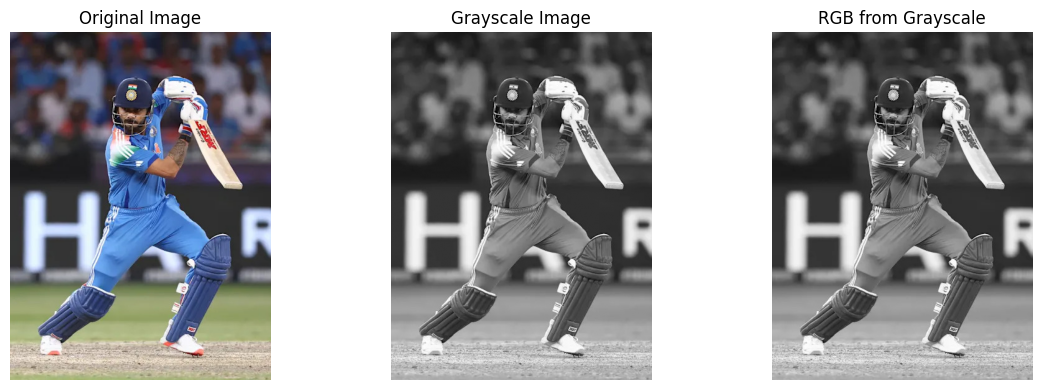

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_bgr = cv2.imread("image.jpg")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

rgb_from_gray = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_from_gray)
plt.title("RGB from Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

3. Use Keras' ImageDataGenerator to apply random rotation and horizontal flip to an image of your choice (for example, a Zomato food pic or an IPL player). Generate and display 4 augmented versions.<br><br><em><strong>Hint:</strong> Set rotation_range and horizontal_flip in ImageDataGenerator, then use flow() or flow_from_directory().</em>


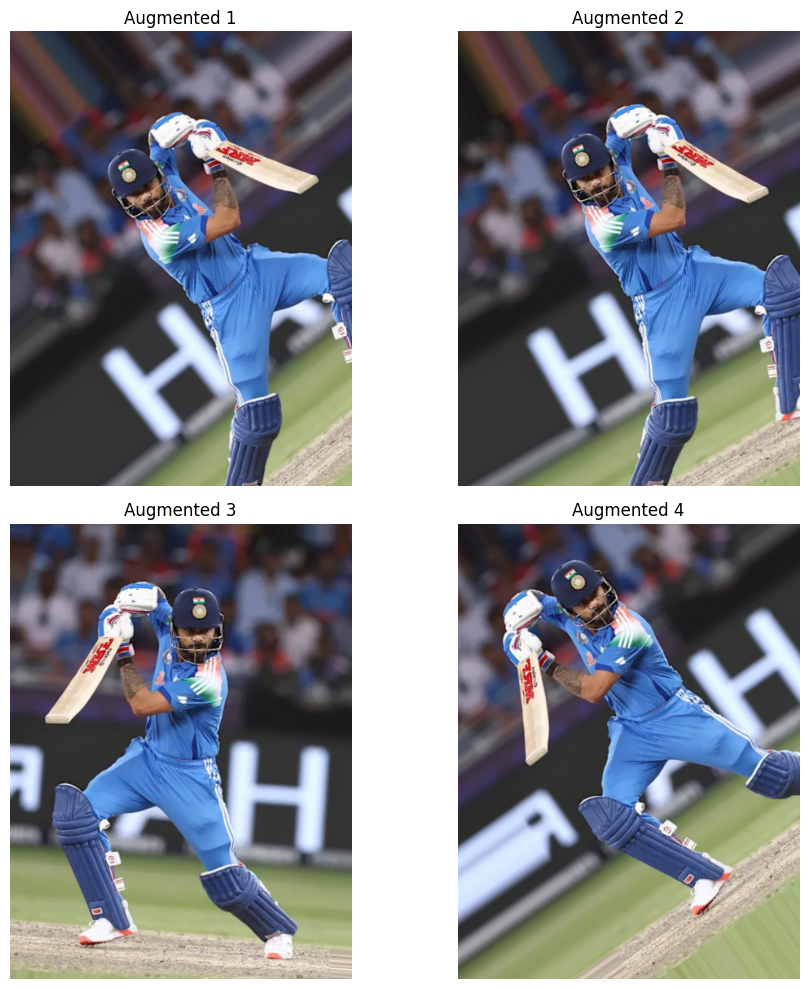

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array


img = load_img("image.jpg") 
img_array = img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)


datagen = ImageDataGenerator(
    rotation_range=40,
    horizontal_flip=True
)

plt.figure(figsize=(10, 10))

i = 0
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(2, 2, i + 1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")
    plt.title(f"Augmented {i+1}")

    i += 1
    if i == 4:
        break

plt.tight_layout()
plt.show()

4. Write code to increase and decrease the brightness of a selfie or any image by 40% using ImageDataGenerator's brightness_range parameter. Show the original, brightened, and darkened images side by side.


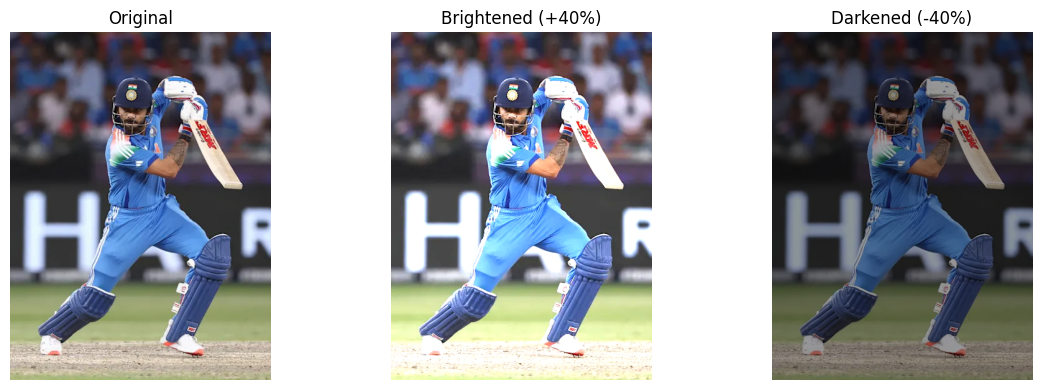

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

img = load_img("image.jpg")  # Replace with your image path
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

bright_gen = ImageDataGenerator(brightness_range=[1.4, 1.4])
bright_img = next(bright_gen.flow(img_array, batch_size=1))[0].astype("uint8")

dark_gen = ImageDataGenerator(brightness_range=[0.6, 0.6])
dark_img = next(dark_gen.flow(img_array, batch_size=1))[0].astype("uint8")

original_img = img_array[0].astype("uint8")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bright_img)
plt.title("Brightened (+40%)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dark_img)
plt.title("Darkened (-40%)")
plt.axis("off")

plt.tight_layout()
plt.show()

5. Pick any meme or cricket image and use ImageDataGenerator to apply a shear transformation. Explain in one line how the image changes visually after shearing.

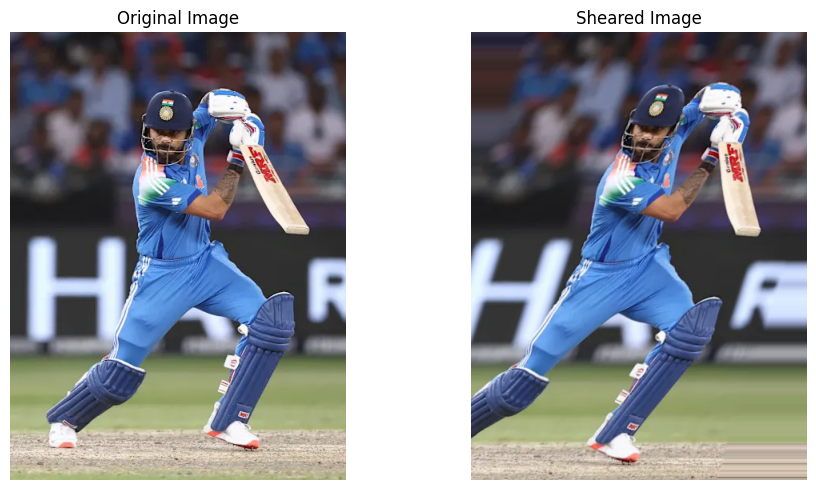

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

img = load_img("image.jpg")  # Replace with your image path
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

datagen = ImageDataGenerator(shear_range=30)

sheared_img = next(datagen.flow(img_array, batch_size=1))[0].astype("uint8")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sheared_img)
plt.title("Sheared Image")
plt.axis("off")

plt.tight_layout()
plt.show()